In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [3]:
# ── Config — change these to test different pairs ─────────────────────────────
STOCK_X = "DDD"   # independent variable (x in regression)
STOCK_Y = "BBB"   # dependent variable  (y in regression, the one being traded)
TRAIN_DAYS = 30

# IND is always used as the risk-free rate for the Sharpe ratio — do not change
RISK_FREE = "IND"

In [4]:
train_data=hist_df[hist_df["day"]<=TRAIN_DAYS]
train_data

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56
...,...,...,...,...,...,...,...,...,...
11725,386,30,386,119.79,242.59,342.71,273.44,179.47,259.54
11726,387,30,387,119.80,242.75,341.49,273.85,179.56,259.40
11727,388,30,388,119.84,243.03,341.18,273.64,179.35,259.29
11728,389,30,389,119.96,243.66,341.53,274.09,179.10,259.59


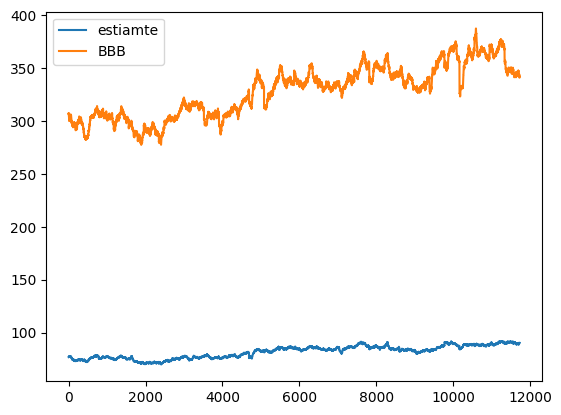

In [5]:
intercept,coef=-0.878753,0.508236
sd=5.79

y_fit=train_data[STOCK_X]*coef+intercept
plt.plot(y_fit, label="estiamte")
plt.plot(train_data[STOCK_Y],label=STOCK_Y)

plt.legend()

In [6]:
train_data.index

RangeIndex(start=0, stop=11730, step=1)

In [7]:
diff=train_data[STOCK_Y]-y_fit
x=np.linspace(1,3,10)
y=np.linspace(0,2,10)
all=[]

for buy_in in x:
    for back in y:
start_capital=1000000
total=start_capital
per=total/2
tot_ETF=0
tot_DDD=0

profit=[1]

for i in train_data.index:
    if(i==0): continue

    if(diff[i]>=buy_in*sd and diff[i-1]<buy_in*sd):
        amount_etf=per//train_data[STOCK_Y][i]
        amount_ind=per//train_data[STOCK_X][i]

        tot_IND+=amount_ind
        tot_ETF-=amount_etf

        total+=amount_etf*train_data[STOCK_Y][i]
        total-=amount_ind*train_data[STOCK_X][i]

        print(tot_ETF,i,total)

    if(diff[i]<=back*sd and diff[i-1]>back*sd and tot_ETF<0):
        total-=tot_ETF*train_data[STOCK_Y][i]
        total+=tot_IND*train_data[STOCK_X][i]
        tot_ETF=0
        tot_IND=0

        print(tot_ETF,i,total)


    profit.append(total/start_capital)



profit=pd.DataFrame(np.array(profit))
#print(total)

Rp=total/start_capital
Rf=(train_data[RISK_FREE].iloc[-1]/train_data[RISK_FREE].iloc[0])
sigma=np.sqrt(profit[0].var())

sharpe=(Rp-Rf)/sigma

IndentationError: expected an indented block after 'for' statement on line 7 (1822293484.py, line 8)

In [ ]:
all.append((sharpe,total,buy_in,back))

all.sort(reverse=True)

for i in range(5):
    print(all[i])